# Capacity vs ICA / Integrated-Voltage SOH Comparison

This notebook builds three SOH-like curves from charge-derived anchor features, but aligns them to the flight-event timeline rather than the charging-event timeline.

1. **Capacity-based anchor SOH** from integrated current on near-full charge events
2. **ICA / integrated-voltage health index** from the charge trace itself
3. **Temperature-normalized anchor SOH** using the near-full capacity anchors

An **observed-SOH reference curve** is also included for comparison only after the same robust outlier removal is applied.

The goal is a simple sanity check: if these independent health proxies are sensible, their long-term curves should roughly agree even if they do not match perfectly point-by-point.

## Setup

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'ml_workspace').exists() and (candidate / 'data').exists():
            return candidate
    raise RuntimeError('Could not locate project root from notebook working directory.')


def resolve_timeseries_path(project_root: Path) -> Path:
    preferred = project_root / 'data' / 'event_timeseries_corrected.parquet'
    fallback = project_root / 'data' / 'event_timeseries.parquet'
    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback
    raise FileNotFoundError('Could not find event_timeseries_corrected.parquet or event_timeseries.parquet under data/.')


PROJECT_ROOT = find_project_root(Path.cwd())
TIMESERIES_PATH = resolve_timeseries_path(PROJECT_ROOT)

PLANE_FOCUS = '166'
RATED_CAPACITY_AH = 29.0
PATTERNS_FULL_SOH = None
PATTERNS_EOL_SOH = None
SOH_ZERO_AT_CAPACITY_PCT = 100.0 * (9.0 / 20.0)
# Derived from POH generic traffic pattern SOC usage (SOH 100 vs SOH 0).
ANCHOR_SOC_PCT = 95.0
ANCHOR_SOC_DELTA_PCT = 20.0
LOW_END_CURRENT_A = 5.0
SPIKE_THRESHOLD_PCT = 2.0
TEMP_REFERENCE_C = 23.0
EDGE_SAMPLES = 25
END_CURRENT_SAMPLES = 50
SMOOTH_WINDOW = 25
IV_WINDOWS_V = [(340.0, 390.0), (345.0, 395.0), (350.0, 395.0), (355.0, 395.0), (360.0, 390.0)]
ICA_WINDOWS_V = [(335.0, 355.0), (340.0, 360.0), (345.0, 365.0), (350.0, 370.0), (355.0, 375.0), (360.0, 380.0)]

plt.style.use('default')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

TIMESERIES_PATH


PosixPath('/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/data/event_timeseries_corrected.parquet')

## Build charge-derived anchor features on the flight-event timeline

For each charge-derived anchor event and battery we compute:

- integrated charge throughput in Ah
- a capacity estimate from charge throughput and SOC delta
- an integrated-voltage-over-time feature on a quasi-constant-current window
- an ICA peak feature from `dQ/dV` on the same voltage window
- end temperature for a simple temperature normalization step
- observed SOH median as a cleaned reference only
- cumulative flight-event index so every anchor point is placed by flights flown, not charges observed

In [6]:
def moving_average(values: np.ndarray, window: int) -> np.ndarray:
    if len(values) == 0:
        return values
    if window <= 1:
        return values.copy()
    return pd.Series(values).rolling(window, center=True, min_periods=1).mean().to_numpy()


def window_name(window_v: tuple[float, float]) -> str:
    lo, hi = window_v
    return f"{int(lo)}_{int(hi)}"


def compute_ivdt_auc(time_s: np.ndarray, voltage_v: np.ndarray, window_v: tuple[float, float]) -> float:
    lo, hi = window_v
    mask = np.isfinite(time_s) & np.isfinite(voltage_v) & (voltage_v >= lo) & (voltage_v <= hi)
    if mask.sum() < 50:
        return np.nan
    t = time_s[mask]
    v = voltage_v[mask]
    if np.nanmax(v) - np.nanmin(v) < (hi - lo) * 0.7:
        return np.nan
    return float(np.trapezoid(v, x=t))


def compute_ica_features(voltage_v: np.ndarray, q_ah: np.ndarray, window: tuple[float, float]) -> tuple[float, float]:
    lo, hi = window
    mask = np.isfinite(voltage_v) & np.isfinite(q_ah) & (voltage_v >= lo) & (voltage_v <= hi)
    if mask.sum() < 50:
        return np.nan, np.nan
    v = moving_average(voltage_v[mask], SMOOTH_WINDOW)
    q = moving_average(q_ah[mask], SMOOTH_WINDOW)
    order = np.argsort(v)
    v = v[order]
    q = q[order]
    uniq_v, idx = np.unique(v, return_index=True)
    v = uniq_v
    q = q[idx]
    if len(v) < 20 or np.nanmax(v) - np.nanmin(v) < (hi - lo) * 0.7:
        return np.nan, np.nan
    grid = np.arange(max(lo, np.floor(v.min() * 10) / 10), min(hi, np.ceil(v.max() * 10) / 10) + 1e-9, 0.1)
    if len(grid) < 20:
        return np.nan, np.nan
    q_grid = np.interp(grid, v, q)
    dqdv = np.gradient(q_grid, grid)
    if len(dqdv) > 10:
        dqdv = dqdv[5:-5]
    peak = float(np.nanmax(dqdv)) if len(dqdv) else np.nan
    dq_window_ah = float(q_grid[-1] - q_grid[0]) if len(q_grid) else np.nan
    return peak, dq_window_ah


def build_flight_index_table(timeseries_path: Path) -> pd.DataFrame:
    cols = [
        'plane_id', 'flight_id', 'event_datetime', 'source_csv_kind', 'source_pack_id', 'is_flight_event'
    ]
    raw = pd.read_parquet(timeseries_path, columns=cols)
    raw = raw[
        raw['source_csv_kind'].eq('aux')
        & raw['source_pack_id'].isin([1, 2])
        & raw['is_flight_event'].eq(1)
    ].copy()
    raw['event_datetime'] = pd.to_datetime(raw['event_datetime'])
    raw = raw.dropna(subset=['event_datetime'])
    raw['plane_id'] = raw['plane_id'].astype(str)
    raw['battery_id'] = raw['source_pack_id'].astype(int)
    raw['flight_id'] = pd.to_numeric(raw['flight_id'], errors='coerce').astype('Int64')
    flight_events = raw.dropna(subset=['flight_id']).drop_duplicates(['plane_id', 'battery_id', 'flight_id', 'event_datetime'])
    flight_events = flight_events.sort_values(['plane_id', 'battery_id', 'event_datetime', 'flight_id']).reset_index(drop=True)
    flight_events['flight_event_index'] = flight_events.groupby(['plane_id', 'battery_id']).cumcount() + 1
    return flight_events[['plane_id', 'battery_id', 'event_datetime', 'flight_event_index']]


def attach_flight_event_index(event_df: pd.DataFrame, flight_index_df: pd.DataFrame) -> pd.DataFrame:
    merged_groups = []
    for (plane_id, battery_id), group in event_df.groupby(['plane_id', 'battery_id'], sort=False):
        left = group.sort_values(['event_datetime', 'flight_id']).copy()
        right = flight_index_df[
            (flight_index_df['plane_id'].eq(plane_id)) & (flight_index_df['battery_id'].eq(battery_id))
        ][['event_datetime', 'flight_event_index']].sort_values('event_datetime').copy()
        if right.empty:
            left['flight_event_index'] = 0
        else:
            left = pd.merge_asof(
                left,
                right,
                on='event_datetime',
                direction='backward',
                allow_exact_matches=True,
            )
            left['flight_event_index'] = left['flight_event_index'].fillna(0).astype(int)
        merged_groups.append(left)
    return pd.concat(merged_groups, ignore_index=True)


def build_charge_feature_table(timeseries_path: Path) -> pd.DataFrame:
    cols = [
        'plane_id', 'flight_id', 'event_datetime', 'source_csv_kind', 'source_pack_id',
        'is_charging_event', 'time_ms',
        ' bat 1 current', ' bat 2 current',
        ' bat 1 voltage', ' bat 2 voltage',
        ' bat 1 soc', ' bat 2 soc',
        ' bat 1 avg cell temp', ' bat 2 avg cell temp',
        ' bat 1 soh', ' bat 2 soh',
    ]
    raw = pd.read_parquet(timeseries_path, columns=cols)
    raw = raw[
        raw['source_csv_kind'].eq('aux')
        & raw['source_pack_id'].isin([1, 2])
        & raw['is_charging_event'].eq(1)
    ].copy()
    raw['event_datetime'] = pd.to_datetime(raw['event_datetime'])
    raw = raw.dropna(subset=['event_datetime'])

    rows = []
    for battery_id in [1, 2]:
        df = raw[raw['source_pack_id'].eq(battery_id)].copy()
        current_col = f' bat {battery_id} current'
        voltage_col = f' bat {battery_id} voltage'
        soc_col = f' bat {battery_id} soc'
        temp_col = f' bat {battery_id} avg cell temp'
        soh_col = f' bat {battery_id} soh'

        for col in [current_col, voltage_col, soc_col, temp_col, soh_col]:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        df = df.sort_values(['plane_id', 'event_datetime', 'flight_id', 'time_ms'])

        for (plane_id, flight_id, event_datetime), group in df.groupby(['plane_id', 'flight_id', 'event_datetime'], sort=False):
            group = group.dropna(subset=['time_ms']).sort_values('time_ms').drop_duplicates('time_ms')
            if len(group) < 100:
                continue

            time_ms = group['time_ms'].to_numpy(dtype=float)
            current_a = group[current_col].to_numpy(dtype=float)
            voltage_v = group[voltage_col].to_numpy(dtype=float)
            soc_pct = group[soc_col].to_numpy(dtype=float)
            temp_c = group[temp_col].to_numpy(dtype=float)
            observed_soh = group[soh_col].to_numpy(dtype=float)

            valid = np.isfinite(time_ms) & np.isfinite(current_a) & np.isfinite(voltage_v) & np.isfinite(soc_pct)
            if valid.sum() < 100:
                continue

            time_ms = time_ms[valid]
            current_a = current_a[valid]
            voltage_v = voltage_v[valid]
            soc_pct = soc_pct[valid]
            temp_c = temp_c[valid]
            observed_soh = observed_soh[valid]

            dt_s = np.diff(time_ms, prepend=time_ms[0]) / 1000.0
            dt_s[dt_s < 0] = 0.0
            charge_current_a = np.maximum(-current_a, 0.0)
            q_ah = np.cumsum(charge_current_a * dt_s / 3600.0)
            time_s = (time_ms - time_ms[0]) / 1000.0

            k = min(EDGE_SAMPLES, len(soc_pct))
            soc_start_pct = float(np.nanmedian(soc_pct[:k]))
            soc_end_pct = float(np.nanmedian(soc_pct[-k:]))
            soc_delta_pct = soc_end_pct - soc_start_pct
            soc_max_pct = float(np.nanmax(soc_pct))
            end_temp_c = float(np.nanmedian(temp_c[-k:])) if np.isfinite(temp_c[-k:]).any() else np.nan
            observed_soh_pct = float(np.nanmedian(observed_soh)) if np.isfinite(observed_soh).any() else np.nan

            charge_ah = float(q_ah[-1] - q_ah[0])
            capacity_est_ah = np.nan
            if soc_delta_pct >= 5:
                capacity_est_ah = float(charge_ah / (soc_delta_pct / 100.0))

            capacity_ratio_pct = np.nan
            capacity_soh_raw_pct = np.nan
            if np.isfinite(capacity_est_ah):
                capacity_ratio_pct = 100.0 * capacity_est_ah / RATED_CAPACITY_AH
                # Map capacity to SOH axis where 0% SOH corresponds to 80% of rated capacity.
                capacity_soh_raw_pct = 100.0 * (capacity_ratio_pct - SOH_ZERO_AT_CAPACITY_PCT) / (100.0 - SOH_ZERO_AT_CAPACITY_PCT)

            qcc_mask = (
                (current_a <= -5.0)
                & (current_a >= -35.0)
                & np.isfinite(current_a)
                & np.isfinite(voltage_v)
                & (voltage_v <= 396.0)
            )
            row = {
                'plane_id': str(plane_id),
                'battery_id': battery_id,
                'flight_id': int(flight_id),
                'event_datetime': event_datetime,
                'soc_start_pct': soc_start_pct,
                'soc_end_pct': soc_end_pct,
                'soc_delta_pct': soc_delta_pct,
                'soc_max_pct': soc_max_pct,
                'end_temp_c': end_temp_c,
                'observed_soh_pct': observed_soh_pct,
                'charge_ah': charge_ah,
                'capacity_est_ah': capacity_est_ah,
                'capacity_ratio_pct': capacity_ratio_pct,
                'capacity_soh_raw_pct': capacity_soh_raw_pct,
            }

            for window_v in IV_WINDOWS_V:
                row[f"ivdt_auc_{window_name(window_v)}"] = np.nan
            for window_v in ICA_WINDOWS_V:
                name = window_name(window_v)
                row[f"ica_peak_{name}"] = np.nan
                row[f"ica_dq_window_ah_{name}"] = np.nan

            if qcc_mask.sum() >= 150:
                qcc_time_s = time_s[qcc_mask]
                qcc_voltage_v = voltage_v[qcc_mask]
                qcc_q_ah = q_ah[qcc_mask]
                for window_v in IV_WINDOWS_V:
                    row[f"ivdt_auc_{window_name(window_v)}"] = compute_ivdt_auc(qcc_time_s, qcc_voltage_v, window_v)
                for window_v in ICA_WINDOWS_V:
                    peak, dq_window_ah = compute_ica_features(qcc_voltage_v, qcc_q_ah, window_v)
                    name = window_name(window_v)
                    row[f"ica_peak_{name}"] = peak
                    row[f"ica_dq_window_ah_{name}"] = dq_window_ah

            rows.append(row)

    event_df = pd.DataFrame(rows)
    event_df = event_df.sort_values(['plane_id', 'battery_id', 'event_datetime', 'flight_id']).reset_index(drop=True)

    flight_index_df = build_flight_index_table(timeseries_path)
    event_df = attach_flight_event_index(event_df, flight_index_df)
    event_df = event_df.sort_values(['plane_id', 'battery_id', 'event_datetime', 'flight_id']).reset_index(drop=True)

    out = []
    for (plane_id, battery_id), group in event_df.groupby(['plane_id', 'battery_id'], sort=False):
        group = group.sort_values(['event_datetime', 'flight_id']).copy()
        group['anchor_basic'] = (group['soc_end_pct'] >= ANCHOR_SOC_PCT) & (group['soc_delta_pct'] >= ANCHOR_SOC_DELTA_PCT)
        group['anchor_strict'] = group['anchor_basic'] & (group['end_temp_c'].notna())
        out.append(group)

    return pd.concat(out, ignore_index=True)


feature_df = build_charge_feature_table(TIMESERIES_PATH)
focus = feature_df[feature_df['plane_id'].eq(PLANE_FOCUS)].copy()
display(focus.head())

,plane_id,battery_id,flight_id,event_datetime,soc_start_pct,soc_end_pct,soc_delta_pct,soc_max_pct,end_temp_c,observed_soh_pct,charge_ah,capacity_est_ah,capacity_ratio_pct,capacity_soh_raw_pct,ivdt_auc_340_390,ivdt_auc_345_395,ivdt_auc_350_395,ivdt_auc_355_395,ivdt_auc_360_390,ica_peak_335_355,ica_dq_window_ah_335_355,ica_peak_340_360,ica_dq_window_ah_340_360,ica_peak_345_365,ica_dq_window_ah_345_365,ica_peak_350_370,ica_dq_window_ah_350_370,ica_peak_355_375,ica_dq_window_ah_355_375,ica_peak_360_380,ica_dq_window_ah_360_380,flight_event_index,anchor_basic,anchor_strict
0,166,1,4575,2023-05-16 11:00:00,77.0,100.0,23.0,100.0,19.0,100.0,6.935145,30.152804,103.975187,107.227613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,True,True
1,166,1,4577,2023-05-16 13:00:00,29.0,100.0,71.0,100.0,23.0,97.0,20.713668,29.174181,100.600623,101.092042,699905.659417,775989.724529,767062.272527,749013.097657,580045.466342,NaN,NaN,NaN,NaN,0.439873,4.311017,0.447594,5.894100,0.447880,7.201527,0.476653,7.161009,0,True,True
2,166,1,4579,2023-05-16 15:00:00,29.0,100.0,71.0,100.0,24.0,96.0,20.539124,28.928343,99.752907,99.550740,661749.294183,738857.797049,734733.910716,725884.791667,565150.863587,NaN,NaN,NaN,NaN,0.444733,3.862124,0.434339,5.495368,0.442383,6.984000,0.455089,7.125105,0,True,True
3,166,1,4581,2023-05-16 20:00:00,27.0,100.0,73.0,100.0,24.0,97.0,20.726906,28.393022,97.906973,96.194497,675488.286866,754249.915695,753760.180289,733866.949636,562870.433730,NaN,NaN,NaN,NaN,0.433211,4.270408,0.433211,5.916486,0.433211,7.144311,0.483323,7.140383,0,True,True
4,166,1,4583,2023-05-16 22:00:00,29.0,51.0,22.0,51.0,24.0,97.0,6.249166,28.405299,97.949306,96.271465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.421441,3.694740,0.430067,5.327994,0.428680,5.377306,NaN,NaN,0,False,False


## Anchor counts and raw capacity proxy

In [7]:
anchor_rows = []
for battery_id, g in focus.groupby('battery_id', sort=False):
    row = {
        'battery_id': battery_id,
        'anchor_events': len(g),
        'basic_anchor_events': int(g['anchor_basic'].sum()),
        'capacity_anchor_median_ah': g.loc[g['anchor_basic'], 'capacity_est_ah'].median(),
        'capacity_anchor_median_soh_pct': g.loc[g['anchor_basic'], 'capacity_soh_raw_pct'].median(),
        'iv_windows_tested': len(IV_WINDOWS_V),
        'ica_windows_tested': len(ICA_WINDOWS_V),
    }
    iv_counts = []
    for window_v in IV_WINDOWS_V:
        iv_counts.append(int((g['anchor_basic'] & g[f"ivdt_auc_{window_name(window_v)}"].notna()).sum()))
    ica_peak_counts = []
    ica_dq_counts = []
    for window_v in ICA_WINDOWS_V:
        name = window_name(window_v)
        ica_peak_counts.append(int((g['anchor_basic'] & g[f"ica_peak_{name}"].notna()).sum()))
        ica_dq_counts.append(int((g['anchor_basic'] & g[f"ica_dq_window_ah_{name}"].notna()).sum()))
    row['max_iv_valid_anchor_events'] = max(iv_counts) if iv_counts else 0
    row['max_ica_peak_valid_anchor_events'] = max(ica_peak_counts) if ica_peak_counts else 0
    row['max_ica_dq_valid_anchor_events'] = max(ica_dq_counts) if ica_dq_counts else 0
    anchor_rows.append(row)
anchor_summary = pd.DataFrame(anchor_rows)
display(anchor_summary.round(3))

,battery_id,anchor_events,basic_anchor_events,capacity_anchor_median_ah,capacity_anchor_median_soh_pct,iv_windows_tested,ica_windows_tested,max_iv_valid_anchor_events,max_ica_peak_valid_anchor_events,max_ica_dq_valid_anchor_events
0,1,306,189,25.87,80.377,5,6,132,96,96
1,2,306,186,26.25,82.762,5,6,130,92,92


## Temperature-normalized capacity anchors

We fit a simple linear temperature correction on the anchor points and adjust capacity SOH to a `23 C` reference.

In [8]:
def add_temp_normalized_capacity(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    slope_rows = []
    for battery_id, group in frame.groupby('battery_id', sort=False):
        g = group.copy()
        anchors = g[g['anchor_basic'] & g['capacity_soh_raw_pct'].notna() & g['end_temp_c'].notna()].copy()
        slope = 0.0
        intercept = np.nan
        if len(anchors) >= 10 and anchors['end_temp_c'].nunique() > 1:
            slope, intercept = np.polyfit(anchors['end_temp_c'], anchors['capacity_soh_raw_pct'], 1)
        g['capacity_soh_tempnorm_pct'] = g['capacity_soh_raw_pct'] - slope * (g['end_temp_c'] - TEMP_REFERENCE_C)
        rows.append(g)
        slope_rows.append({
            'battery_id': battery_id,
            'temp_slope_pct_per_c': slope,
            'temp_intercept': intercept,
            'anchor_temp_corr_spearman': anchors['capacity_soh_raw_pct'].corr(anchors['end_temp_c'], method='spearman'),
        })
    return pd.concat(rows, ignore_index=True), pd.DataFrame(slope_rows)


focus, temp_model_summary = add_temp_normalized_capacity(focus)
display(temp_model_summary.round(4))

,battery_id,temp_slope_pct_per_c,temp_intercept,anchor_temp_corr_spearman
0,1,0.1060,73.0879,-0.1015
1,2,0.1027,74.4328,-0.0905


## Build cleaned observation series and window sweeps

ICA and IV are treated as separate methods here. Each candidate window is cleaned with the same robust outlier-removal step, then converted to a common relative scale normalized to `100` near the start of each battery timeline.

There is no monotone fitting in this section. The notebook ranks ICA and IV windows separately against the temperature-normalized capacity anchor, then plots the best-performing ICA window and best-performing IV window for each battery.

- `capacity_obs_rel_pct`
- `capacity_tempnorm_obs_rel_pct`
- `ica_obs_rel_<window>` for each ICA window
- `iv_obs_rel_<window>` for each IV window
- `observed_obs_rel_pct` as a cleaned observed-SOH reference only

In [9]:
def remove_massive_outliers(feature: pd.Series, edge_points: int = 3, ref_points: int = 10, z_thresh: float = 6.0) -> pd.Series:
    out = feature.astype(float).copy()
    valid = out.notna()
    if valid.sum() < 8:
        return out

    med = out.loc[valid].median()
    mad = (out.loc[valid] - med).abs().median()
    if not np.isfinite(mad) or mad == 0:
        mad = out.loc[valid].std()

    if np.isfinite(mad) and mad > 0:
        robust_z = 0.6745 * (out - med).abs() / mad
        out.loc[robust_z > z_thresh] = np.nan

    ref = out.iloc[edge_points : edge_points + ref_points].dropna()
    if len(ref) >= 3:
        ref_med = ref.median()
        if np.isfinite(ref_med) and ref_med != 0:
            for idx in out.index[:edge_points]:
                val = out.loc[idx]
                if not np.isfinite(val):
                    continue
                ratio = val / ref_med
                if (ratio > 3.0) or (ratio < (1.0 / 3.0)):
                    out.loc[idx] = np.nan

    return out


def feature_to_relative_health(feature: pd.Series, flight_event_index: pd.Series) -> pd.Series:
    out = pd.Series(np.nan, index=feature.index, dtype=float)
    valid = feature.notna() & flight_event_index.notna()
    if valid.sum() < 5:
        return out
    feat = feature.loc[valid].astype(float)
    idx = flight_event_index.loc[valid].astype(float)
    baseline = feat.iloc[: min(10, len(feat))].median()
    if not np.isfinite(baseline) or baseline == 0:
        return out
    corr = feat.corr(idx, method='spearman')
    if np.isnan(corr):
        corr = -1.0
    if corr <= 0:
        rel = 100.0 * feat / baseline
    else:
        rel = 100.0 * baseline / feat
    out.loc[valid] = rel.to_numpy()
    return out


def normalize_observation(feature: pd.Series) -> pd.Series:
    out = pd.Series(np.nan, index=feature.index, dtype=float)
    valid = feature.dropna().astype(float)
    if len(valid) < 3:
        return out
    baseline = valid.iloc[: min(10, len(valid))].median()
    if not np.isfinite(baseline) or baseline == 0:
        return out
    out.loc[valid.index] = 100.0 * valid / baseline
    return out


curve_rows = []
curve_summary_rows = []
ica_window_summary_rows = []
iv_window_summary_rows = []
best_window_rows = []

for battery_id, group in focus.groupby('battery_id', sort=False):
    g = group.sort_values(['event_datetime', 'flight_id']).copy()

    g['capacity_soh_raw_clean_pct'] = remove_massive_outliers(g['capacity_soh_raw_pct'])
    g['capacity_soh_tempnorm_clean_pct'] = remove_massive_outliers(g['capacity_soh_tempnorm_pct'])
    g['observed_soh_clean_pct'] = remove_massive_outliers(g['observed_soh_pct'])

    g['capacity_obs_rel_pct'] = normalize_observation(g['capacity_soh_raw_clean_pct'])
    g['capacity_tempnorm_obs_rel_pct'] = normalize_observation(g['capacity_soh_tempnorm_clean_pct'])
    g['observed_obs_rel_pct'] = normalize_observation(g['observed_soh_clean_pct'])

    best_ica = {'window_name': None, 'corr_to_tempnorm': -np.inf}
    for window_v in ICA_WINDOWS_V:
        name = window_name(window_v)
        peak_col = f'ica_peak_{name}'
        dq_col = f'ica_dq_window_ah_{name}'
        peak_clean_col = f'{peak_col}_clean'
        dq_clean_col = f'{dq_col}_clean'
        peak_rel_col = f'{peak_col}_rel'
        dq_rel_col = f'{dq_col}_rel'
        ica_rel_col = f'ica_obs_rel_{name}'

        g[peak_clean_col] = remove_massive_outliers(g[peak_col])
        g[dq_clean_col] = remove_massive_outliers(g[dq_col])
        g[peak_rel_col] = feature_to_relative_health(g[peak_clean_col], g['flight_event_index'])
        g[dq_rel_col] = feature_to_relative_health(g[dq_clean_col], g['flight_event_index'])
        g[ica_rel_col] = g[[peak_rel_col, dq_rel_col]].mean(axis=1)

        overlap = g[['capacity_tempnorm_obs_rel_pct', ica_rel_col]].dropna()
        corr = overlap['capacity_tempnorm_obs_rel_pct'].corr(overlap[ica_rel_col]) if len(overlap) >= 5 else np.nan
        ica_window_summary_rows.append({
            'battery_id': battery_id,
            'window_name': name,
            'window_v': f'{window_v[0]:.0f}-{window_v[1]:.0f}',
            'n_points': int(g[ica_rel_col].notna().sum()),
            'corr_to_tempnorm_capacity': corr,
            'peak_outliers_removed': int(g[peak_col].notna().sum() - g[peak_clean_col].notna().sum()),
            'dq_outliers_removed': int(g[dq_col].notna().sum() - g[dq_clean_col].notna().sum()),
        })
        if np.isfinite(corr) and corr > best_ica['corr_to_tempnorm']:
            best_ica = {'window_name': name, 'corr_to_tempnorm': corr}

    best_iv = {'window_name': None, 'corr_to_tempnorm': -np.inf}
    for window_v in IV_WINDOWS_V:
        name = window_name(window_v)
        iv_col = f'ivdt_auc_{name}'
        iv_clean_col = f'{iv_col}_clean'
        iv_rel_col = f'iv_obs_rel_{name}'

        g[iv_clean_col] = remove_massive_outliers(g[iv_col])
        g[iv_rel_col] = feature_to_relative_health(g[iv_clean_col], g['flight_event_index'])

        overlap = g[['capacity_tempnorm_obs_rel_pct', iv_rel_col]].dropna()
        corr = overlap['capacity_tempnorm_obs_rel_pct'].corr(overlap[iv_rel_col]) if len(overlap) >= 5 else np.nan
        iv_window_summary_rows.append({
            'battery_id': battery_id,
            'window_name': name,
            'window_v': f'{window_v[0]:.0f}-{window_v[1]:.0f}',
            'n_points': int(g[iv_rel_col].notna().sum()),
            'corr_to_tempnorm_capacity': corr,
            'auc_outliers_removed': int(g[iv_col].notna().sum() - g[iv_clean_col].notna().sum()),
        })
        if np.isfinite(corr) and corr > best_iv['corr_to_tempnorm']:
            best_iv = {'window_name': name, 'corr_to_tempnorm': corr}

    g['best_ica_obs_rel_pct'] = g[f"ica_obs_rel_{best_ica['window_name']}"] if best_ica['window_name'] is not None else np.nan
    g['best_iv_obs_rel_pct'] = g[f"iv_obs_rel_{best_iv['window_name']}"] if best_iv['window_name'] is not None else np.nan
    g['best_ica_window_name'] = best_ica['window_name']
    g['best_iv_window_name'] = best_iv['window_name']

    best_window_rows.append({
        'battery_id': battery_id,
        'best_ica_window_name': best_ica['window_name'],
        'best_ica_corr_to_tempnorm': best_ica['corr_to_tempnorm'] if np.isfinite(best_ica['corr_to_tempnorm']) else np.nan,
        'best_iv_window_name': best_iv['window_name'],
        'best_iv_corr_to_tempnorm': best_iv['corr_to_tempnorm'] if np.isfinite(best_iv['corr_to_tempnorm']) else np.nan,
    })

    curve_summary_rows.append({
        'battery_id': battery_id,
        'n_anchor_points': int(g['anchor_basic'].sum()),
        'capacity_raw_outliers_removed': int(g['capacity_soh_raw_pct'].notna().sum() - g['capacity_soh_raw_clean_pct'].notna().sum()),
        'capacity_tempnorm_outliers_removed': int(g['capacity_soh_tempnorm_pct'].notna().sum() - g['capacity_soh_tempnorm_clean_pct'].notna().sum()),
        'observed_outliers_removed': int(g['observed_soh_pct'].notna().sum() - g['observed_soh_clean_pct'].notna().sum()),
        'n_capacity_obs_points': int(g['capacity_obs_rel_pct'].notna().sum()),
        'n_tempnorm_obs_points': int(g['capacity_tempnorm_obs_rel_pct'].notna().sum()),
        'n_observed_ref_points': int(g['observed_obs_rel_pct'].notna().sum()),
    })

    curve_rows.append(g)

curve_df = pd.concat(curve_rows, ignore_index=True)
curve_summary = pd.DataFrame(curve_summary_rows)
ica_window_summary = pd.DataFrame(ica_window_summary_rows)
iv_window_summary = pd.DataFrame(iv_window_summary_rows)
best_windows = pd.DataFrame(best_window_rows)
display(curve_summary.round(3))
display(best_windows.round(3))

,battery_id,n_anchor_points,capacity_raw_outliers_removed,capacity_tempnorm_outliers_removed,observed_outliers_removed,n_capacity_obs_points,n_tempnorm_obs_points,n_observed_ref_points
0,1,189,9,9,0,289,289,306
1,2,186,9,9,0,289,289,306


,battery_id,best_ica_window_name,best_ica_corr_to_tempnorm,best_iv_window_name,best_iv_corr_to_tempnorm
0,1,355_375,0.528,350_395,0.296
1,2,355_375,0.567,350_395,0.278


## Overlay the best ICA and best IV windows over time

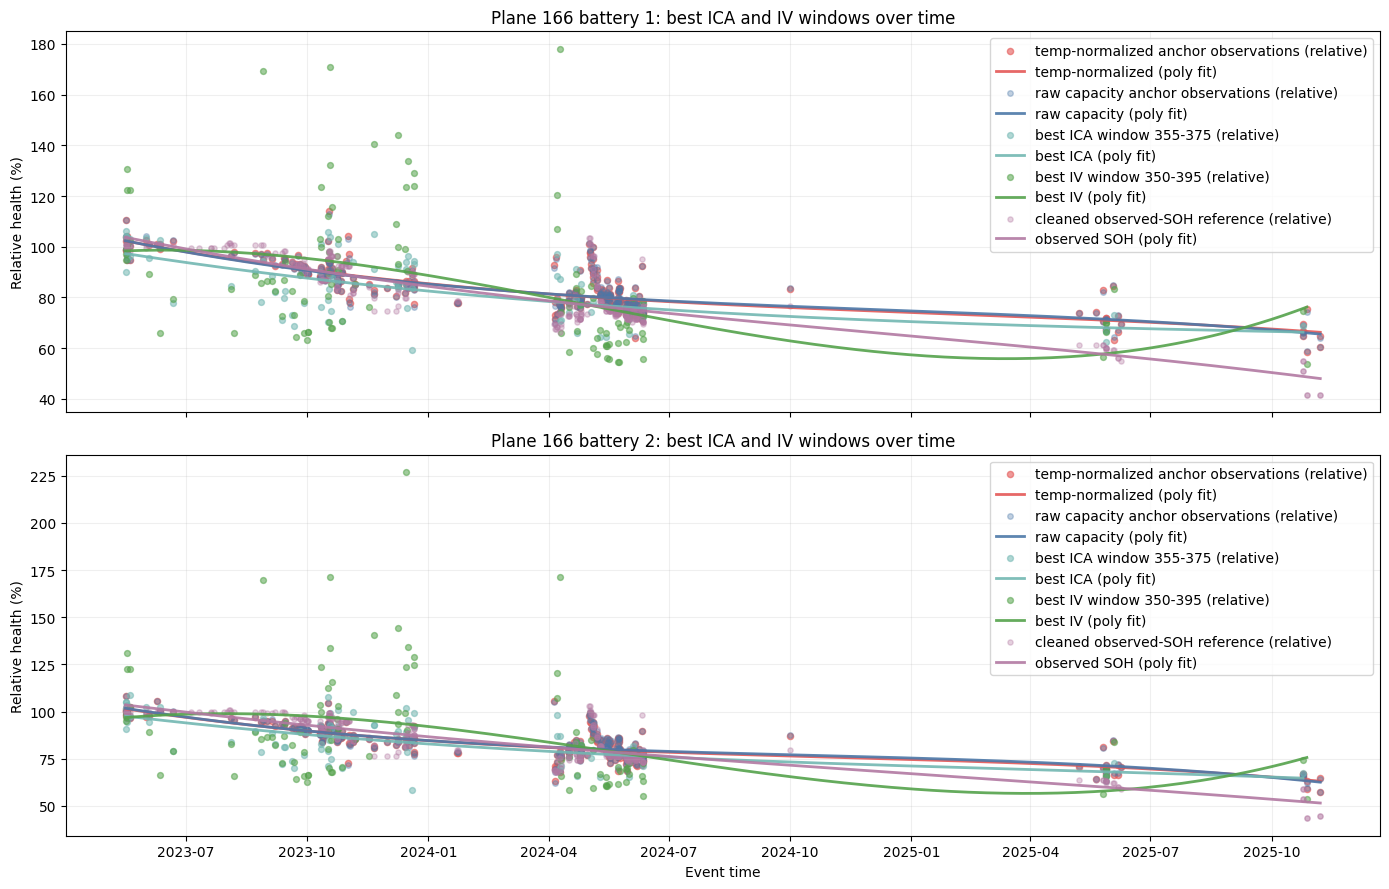

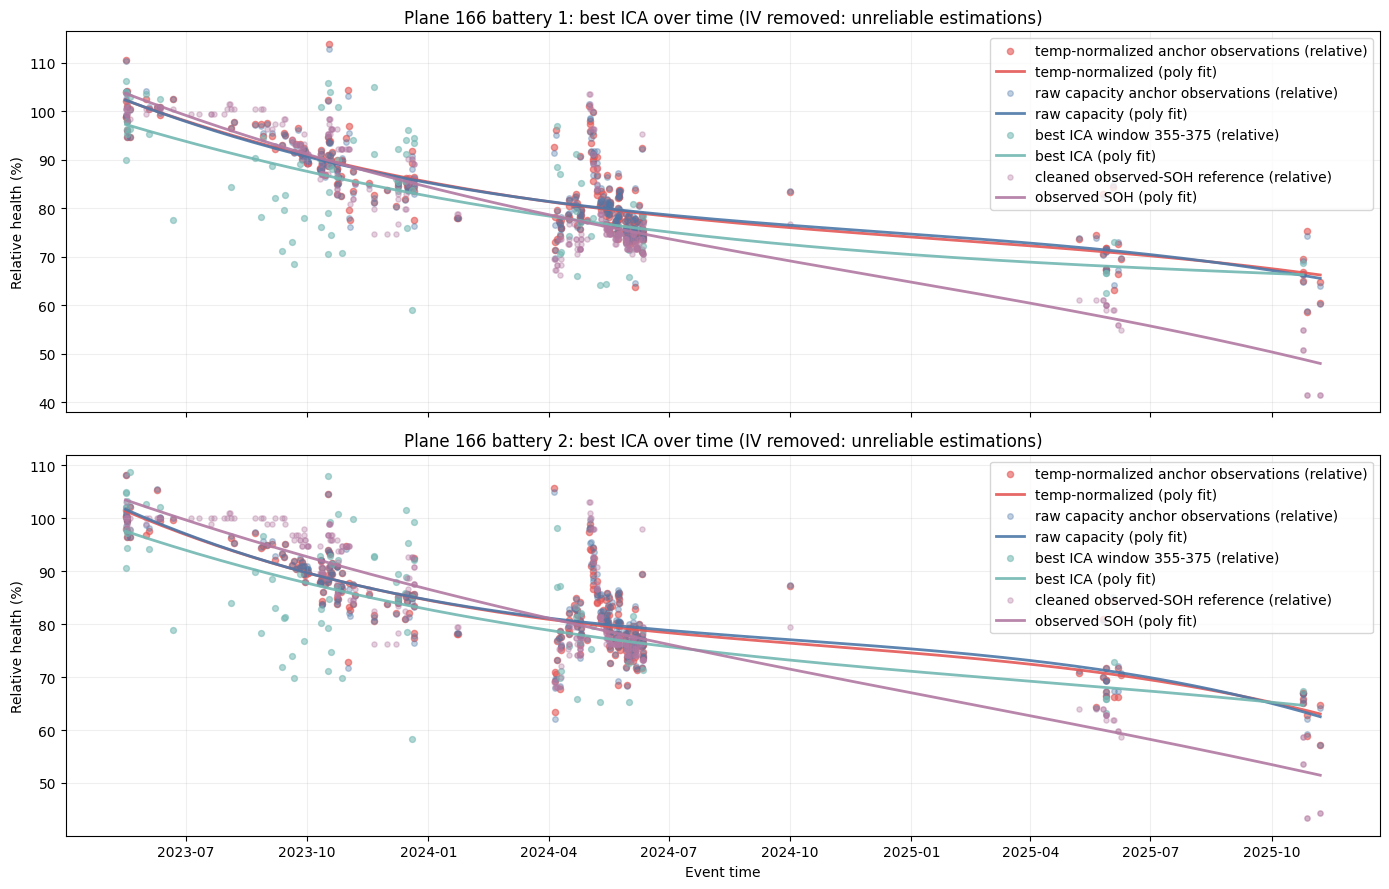

In [10]:
import matplotlib.dates as mdates

POLY_DEGREE = 3


def plot_poly_fit(ax, x, y, degree=POLY_DEGREE, color="#000000", label=None, lw=2):
    x = pd.Series(x)
    y = pd.Series(y)
    is_dt = pd.api.types.is_datetime64_any_dtype(x)
    if is_dt:
        x_num = pd.to_datetime(x)
        x_num = mdates.date2num(x_num)
    else:
        x_num = pd.to_numeric(x, errors="coerce")
    mask = np.isfinite(x_num) & y.notna()
    if mask.sum() < max(5, degree + 2):
        return
    x_num = np.asarray(x_num)[mask]
    y_num = y.loc[mask].astype(float).to_numpy()
    order = np.argsort(x_num)
    x_num = x_num[order]
    y_num = y_num[order]
    coeff = np.polyfit(x_num, y_num, degree)
    poly = np.poly1d(coeff)
    x_fit = np.linspace(float(np.min(x_num)), float(np.max(x_num)), 200)
    y_fit = poly(x_fit)
    if is_dt:
        x_plot = mdates.num2date(x_fit)
    else:
        x_plot = x_fit
    ax.plot(x_plot, y_fit, color=color, linewidth=lw, alpha=0.9, label=label)


# Original plot (includes IV)
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for i, battery_id in enumerate([1, 2]):
    g = curve_df[curve_df['battery_id'].eq(battery_id)].sort_values(['event_datetime', 'flight_id']).copy()
    best = best_windows[best_windows['battery_id'].eq(battery_id)].iloc[0]
    best_ica_col = f"ica_obs_rel_{best['best_ica_window_name']}" if pd.notna(best['best_ica_window_name']) else None
    best_iv_col = f"iv_obs_rel_{best['best_iv_window_name']}" if pd.notna(best['best_iv_window_name']) else None
    ax = axes[i]
    ax.scatter(g['event_datetime'], g['capacity_tempnorm_obs_rel_pct'], s=20, alpha=0.60, color='#e45756', label='temp-normalized anchor observations (relative)')
    plot_poly_fit(ax, g['event_datetime'], g['capacity_tempnorm_obs_rel_pct'], color='#e45756', label='temp-normalized (poly fit)')
    ax.scatter(g['event_datetime'], g['capacity_obs_rel_pct'], s=16, alpha=0.35, color='#4c78a8', label='raw capacity anchor observations (relative)')
    plot_poly_fit(ax, g['event_datetime'], g['capacity_obs_rel_pct'], color='#4c78a8', label='raw capacity (poly fit)')
    if best_ica_col is not None:
        ax.scatter(g['event_datetime'], g[best_ica_col], s=18, alpha=0.55, color='#72b7b2', label=f"best ICA window {best['best_ica_window_name'].replace('_', '-')} (relative)")
        plot_poly_fit(ax, g['event_datetime'], g[best_ica_col], color='#72b7b2', label='best ICA (poly fit)')
    if best_iv_col is not None:
        ax.scatter(g['event_datetime'], g[best_iv_col], s=18, alpha=0.55, color='#54a24b', label=f"best IV window {best['best_iv_window_name'].replace('_', '-')} (relative)")
        plot_poly_fit(ax, g['event_datetime'], g[best_iv_col], color='#54a24b', label='best IV (poly fit)')
    ax.scatter(g['event_datetime'], g['observed_obs_rel_pct'], s=14, alpha=0.35, color='#b279a2', label='cleaned observed-SOH reference (relative)')
    plot_poly_fit(ax, g['event_datetime'], g['observed_obs_rel_pct'], color='#b279a2', label='observed SOH (poly fit)')
    ax.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: best ICA and IV windows over time')
    ax.set_ylabel('Relative health (%)')
    ax.grid(alpha=0.2)
    ax.legend(loc='best')

axes[-1].set_xlabel('Event time')
plt.tight_layout()
plt.show()


# Additional plot (IV removed due to unreliable estimations)
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for i, battery_id in enumerate([1, 2]):
    g = curve_df[curve_df['battery_id'].eq(battery_id)].sort_values(['event_datetime', 'flight_id']).copy()
    best = best_windows[best_windows['battery_id'].eq(battery_id)].iloc[0]
    best_ica_col = f"ica_obs_rel_{best['best_ica_window_name']}" if pd.notna(best['best_ica_window_name']) else None
    ax = axes[i]
    ax.scatter(g['event_datetime'], g['capacity_tempnorm_obs_rel_pct'], s=20, alpha=0.60, color='#e45756', label='temp-normalized anchor observations (relative)')
    plot_poly_fit(ax, g['event_datetime'], g['capacity_tempnorm_obs_rel_pct'], color='#e45756', label='temp-normalized (poly fit)')
    ax.scatter(g['event_datetime'], g['capacity_obs_rel_pct'], s=16, alpha=0.35, color='#4c78a8', label='raw capacity anchor observations (relative)')
    plot_poly_fit(ax, g['event_datetime'], g['capacity_obs_rel_pct'], color='#4c78a8', label='raw capacity (poly fit)')
    if best_ica_col is not None:
        ax.scatter(g['event_datetime'], g[best_ica_col], s=18, alpha=0.55, color='#72b7b2', label=f"best ICA window {best['best_ica_window_name'].replace('_', '-')} (relative)")
        plot_poly_fit(ax, g['event_datetime'], g[best_ica_col], color='#72b7b2', label='best ICA (poly fit)')
    ax.scatter(g['event_datetime'], g['observed_obs_rel_pct'], s=14, alpha=0.35, color='#b279a2', label='cleaned observed-SOH reference (relative)')
    plot_poly_fit(ax, g['event_datetime'], g['observed_obs_rel_pct'], color='#b279a2', label='observed SOH (poly fit)')
    ax.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: best ICA over time (IV removed: unreliable estimations)')
    ax.set_ylabel('Relative health (%)')
    ax.grid(alpha=0.2)
    ax.legend(loc='best')

axes[-1].set_xlabel('Event time')
plt.tight_layout()
plt.show()


## Same best ICA and best IV windows by flight-event index

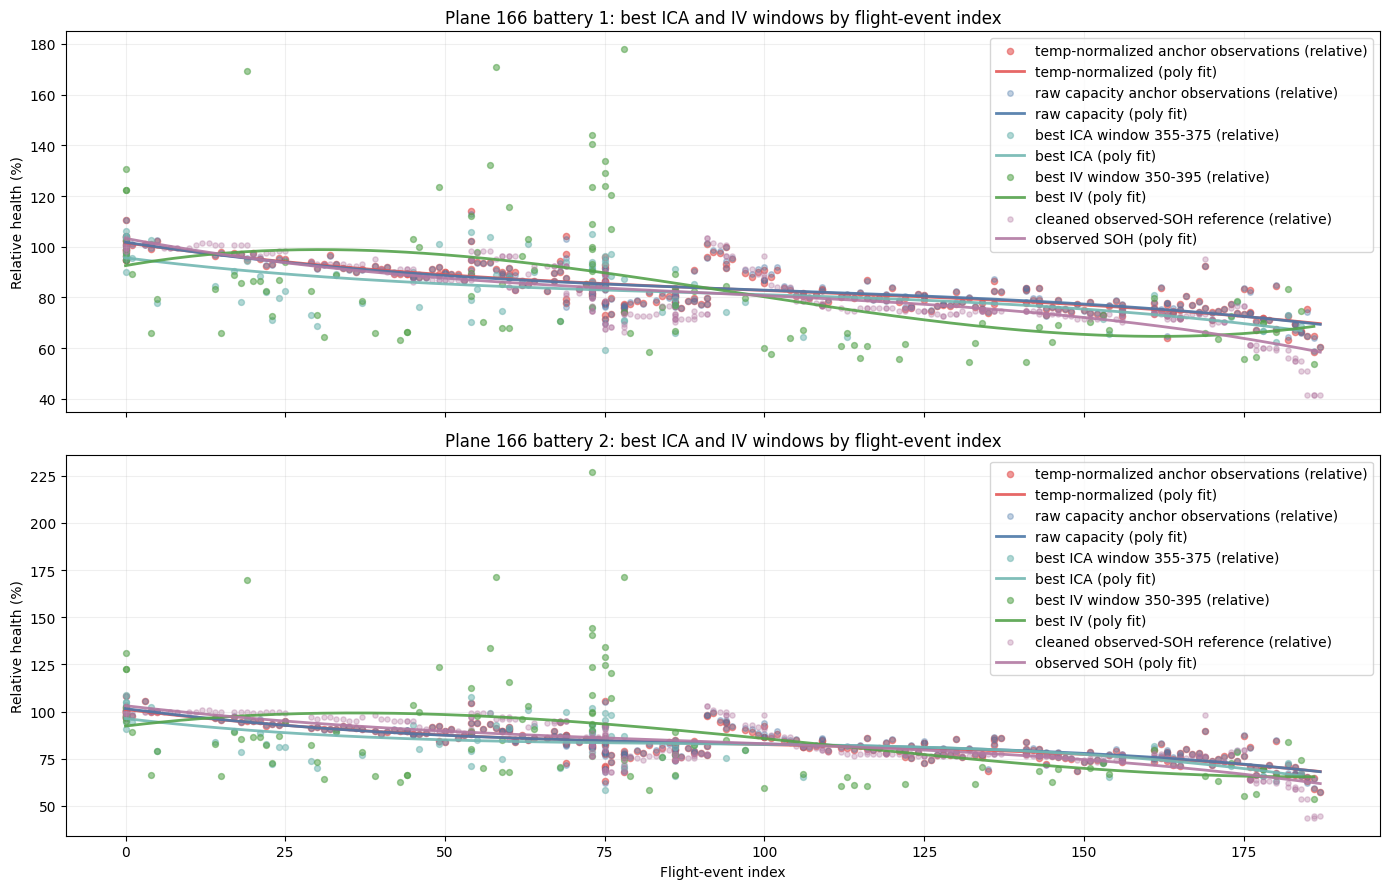

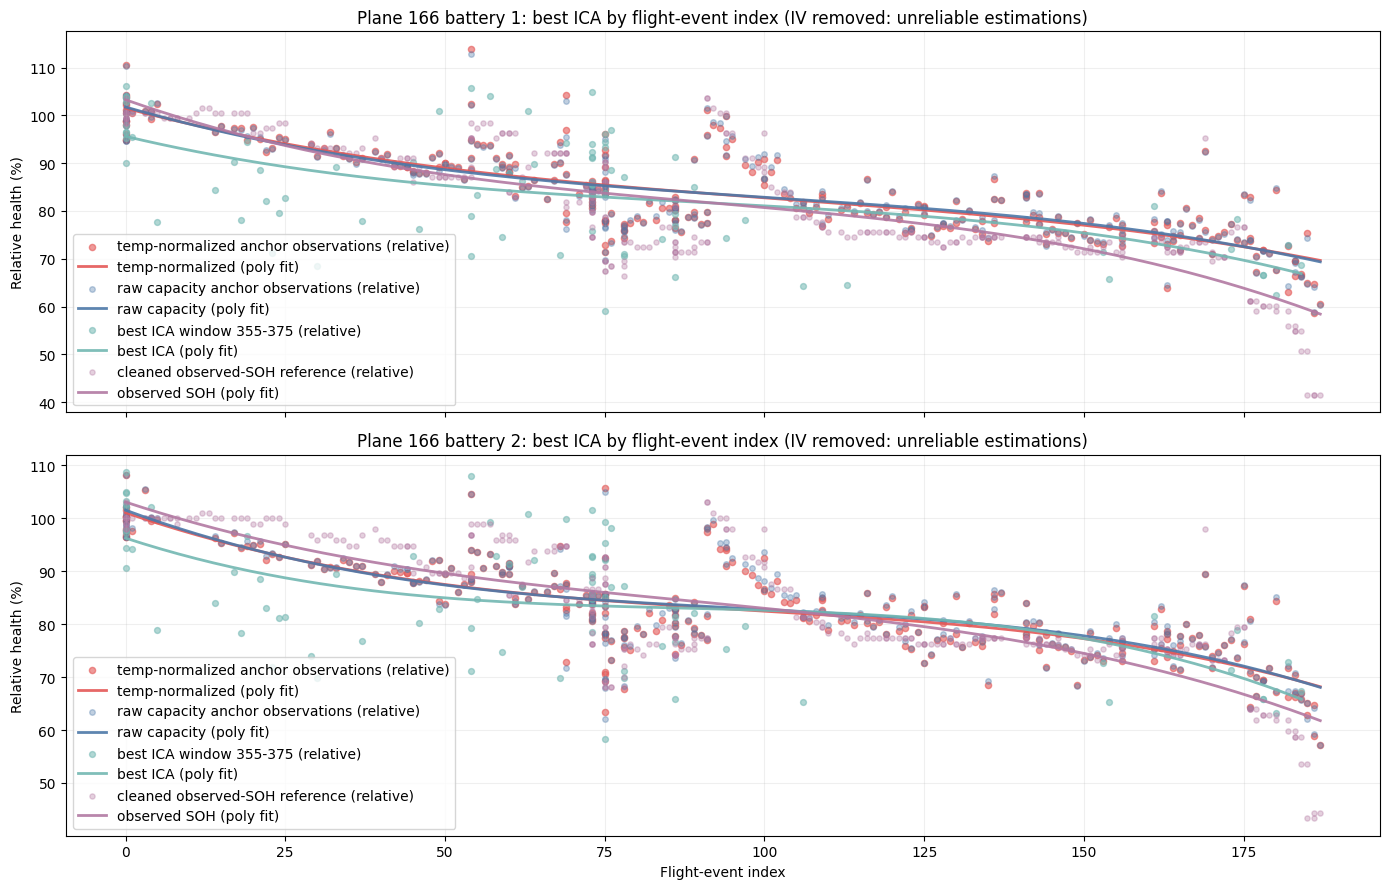

In [11]:
POLY_DEGREE = 3


def plot_poly_fit(ax, x, y, degree=POLY_DEGREE, color="#000000", label=None, lw=2):
    x_num = pd.to_numeric(pd.Series(x), errors="coerce")
    y_num = pd.Series(y)
    mask = np.isfinite(x_num) & y_num.notna()
    if mask.sum() < max(5, degree + 2):
        return
    x_num = np.asarray(x_num)[mask]
    y_num = y_num.loc[mask].astype(float).to_numpy()
    order = np.argsort(x_num)
    x_num = x_num[order]
    y_num = y_num[order]
    coeff = np.polyfit(x_num, y_num, degree)
    poly = np.poly1d(coeff)
    x_fit = np.linspace(float(np.min(x_num)), float(np.max(x_num)), 200)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, color=color, linewidth=lw, alpha=0.9, label=label)


# Original plot (includes IV)
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for i, battery_id in enumerate([1, 2]):
    g = curve_df[curve_df['battery_id'].eq(battery_id)].sort_values(['event_datetime', 'flight_id']).copy()
    best = best_windows[best_windows['battery_id'].eq(battery_id)].iloc[0]
    best_ica_col = f"ica_obs_rel_{best['best_ica_window_name']}" if pd.notna(best['best_ica_window_name']) else None
    best_iv_col = f"iv_obs_rel_{best['best_iv_window_name']}" if pd.notna(best['best_iv_window_name']) else None
    ax = axes[i]
    ax.scatter(g['flight_event_index'], g['capacity_tempnorm_obs_rel_pct'], s=20, alpha=0.60, color='#e45756', label='temp-normalized anchor observations (relative)')
    plot_poly_fit(ax, g['flight_event_index'], g['capacity_tempnorm_obs_rel_pct'], color='#e45756', label='temp-normalized (poly fit)')
    ax.scatter(g['flight_event_index'], g['capacity_obs_rel_pct'], s=16, alpha=0.35, color='#4c78a8', label='raw capacity anchor observations (relative)')
    plot_poly_fit(ax, g['flight_event_index'], g['capacity_obs_rel_pct'], color='#4c78a8', label='raw capacity (poly fit)')
    if best_ica_col is not None:
        ax.scatter(g['flight_event_index'], g[best_ica_col], s=18, alpha=0.55, color='#72b7b2', label=f"best ICA window {best['best_ica_window_name'].replace('_', '-')} (relative)")
        plot_poly_fit(ax, g['flight_event_index'], g[best_ica_col], color='#72b7b2', label='best ICA (poly fit)')
    if best_iv_col is not None:
        ax.scatter(g['flight_event_index'], g[best_iv_col], s=18, alpha=0.55, color='#54a24b', label=f"best IV window {best['best_iv_window_name'].replace('_', '-')} (relative)")
        plot_poly_fit(ax, g['flight_event_index'], g[best_iv_col], color='#54a24b', label='best IV (poly fit)')
    ax.scatter(g['flight_event_index'], g['observed_obs_rel_pct'], s=14, alpha=0.35, color='#b279a2', label='cleaned observed-SOH reference (relative)')
    plot_poly_fit(ax, g['flight_event_index'], g['observed_obs_rel_pct'], color='#b279a2', label='observed SOH (poly fit)')
    ax.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: best ICA and IV windows by flight-event index')
    ax.set_ylabel('Relative health (%)')
    ax.grid(alpha=0.2)
    ax.legend(loc='best')

axes[-1].set_xlabel('Flight-event index')
plt.tight_layout()
plt.show()


# Additional plot (IV removed due to unreliable estimations)
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for i, battery_id in enumerate([1, 2]):
    g = curve_df[curve_df['battery_id'].eq(battery_id)].sort_values(['event_datetime', 'flight_id']).copy()
    best = best_windows[best_windows['battery_id'].eq(battery_id)].iloc[0]
    best_ica_col = f"ica_obs_rel_{best['best_ica_window_name']}" if pd.notna(best['best_ica_window_name']) else None
    ax = axes[i]
    ax.scatter(g['flight_event_index'], g['capacity_tempnorm_obs_rel_pct'], s=20, alpha=0.60, color='#e45756', label='temp-normalized anchor observations (relative)')
    plot_poly_fit(ax, g['flight_event_index'], g['capacity_tempnorm_obs_rel_pct'], color='#e45756', label='temp-normalized (poly fit)')
    ax.scatter(g['flight_event_index'], g['capacity_obs_rel_pct'], s=16, alpha=0.35, color='#4c78a8', label='raw capacity anchor observations (relative)')
    plot_poly_fit(ax, g['flight_event_index'], g['capacity_obs_rel_pct'], color='#4c78a8', label='raw capacity (poly fit)')
    if best_ica_col is not None:
        ax.scatter(g['flight_event_index'], g[best_ica_col], s=18, alpha=0.55, color='#72b7b2', label=f"best ICA window {best['best_ica_window_name'].replace('_', '-')} (relative)")
        plot_poly_fit(ax, g['flight_event_index'], g[best_ica_col], color='#72b7b2', label='best ICA (poly fit)')
    ax.scatter(g['flight_event_index'], g['observed_obs_rel_pct'], s=14, alpha=0.35, color='#b279a2', label='cleaned observed-SOH reference (relative)')
    plot_poly_fit(ax, g['flight_event_index'], g['observed_obs_rel_pct'], color='#b279a2', label='observed SOH (poly fit)')
    ax.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: best ICA by flight-event index (IV removed: unreliable estimations)')
    ax.set_ylabel('Relative health (%)')
    ax.grid(alpha=0.2)
    ax.legend(loc='best')

axes[-1].set_xlabel('Flight-event index')
plt.tight_layout()
plt.show()


## ICA and IV window ranking diagnostics

In [12]:
display(ica_window_summary.sort_values(['battery_id', 'corr_to_tempnorm_capacity'], ascending=[True, False]).round(3))
display(iv_window_summary.sort_values(['battery_id', 'corr_to_tempnorm_capacity'], ascending=[True, False]).round(3))

diag_rows = []
for battery_id, g in curve_df.groupby('battery_id', sort=False):
    best = best_windows[best_windows['battery_id'].eq(battery_id)].iloc[0]
    best_ica_col = f"ica_obs_rel_{best['best_ica_window_name']}" if pd.notna(best['best_ica_window_name']) else None
    best_iv_col = f"iv_obs_rel_{best['best_iv_window_name']}" if pd.notna(best['best_iv_window_name']) else None
    cols = ['capacity_obs_rel_pct', 'capacity_tempnorm_obs_rel_pct', 'observed_obs_rel_pct']
    if best_ica_col is not None:
        cols.append(best_ica_col)
    if best_iv_col is not None:
        cols.append(best_iv_col)
    overlap = g[cols].dropna()
    diag_rows.append({
        'battery_id': battery_id,
        'best_ica_window_name': best['best_ica_window_name'],
        'best_iv_window_name': best['best_iv_window_name'],
        'corr_capacity_vs_tempnorm': overlap['capacity_obs_rel_pct'].corr(overlap['capacity_tempnorm_obs_rel_pct']) if len(overlap) >= 5 else np.nan,
        'corr_tempnorm_vs_best_ica': overlap['capacity_tempnorm_obs_rel_pct'].corr(overlap[best_ica_col]) if best_ica_col is not None and len(overlap) >= 5 else np.nan,
        'corr_tempnorm_vs_best_iv': overlap['capacity_tempnorm_obs_rel_pct'].corr(overlap[best_iv_col]) if best_iv_col is not None and len(overlap) >= 5 else np.nan,
        'corr_best_ica_vs_observed_ref': overlap[best_ica_col].corr(overlap['observed_obs_rel_pct']) if best_ica_col is not None and len(overlap) >= 5 else np.nan,
        'corr_best_iv_vs_observed_ref': overlap[best_iv_col].corr(overlap['observed_obs_rel_pct']) if best_iv_col is not None and len(overlap) >= 5 else np.nan,
        'median_capacity_obs_rel_pct': float(overlap['capacity_obs_rel_pct'].median()) if len(overlap) >= 1 else np.nan,
        'median_tempnorm_obs_rel_pct': float(overlap['capacity_tempnorm_obs_rel_pct'].median()) if len(overlap) >= 1 else np.nan,
        'median_best_ica_obs_rel_pct': float(overlap[best_ica_col].median()) if best_ica_col is not None and len(overlap) >= 1 else np.nan,
        'median_best_iv_obs_rel_pct': float(overlap[best_iv_col].median()) if best_iv_col is not None and len(overlap) >= 1 else np.nan,
        'median_observed_ref_rel_pct': float(overlap['observed_obs_rel_pct'].median()) if len(overlap) >= 1 else np.nan,
    })
display(pd.DataFrame(diag_rows).round(3))


,battery_id,window_name,window_v,n_points,corr_to_tempnorm_capacity,peak_outliers_removed,dq_outliers_removed
4,1,355_375,355-375,83,0.528,6,0
5,1,360_380,360-380,128,0.487,8,0
3,1,350_370,350-370,58,0.411,3,0
2,1,345_365,345-365,17,0.221,2,0
0,1,335_355,335-355,0,NaN,0,0
1,1,340_360,340-360,0,NaN,0,0
10,2,355_375,355-375,82,0.567,6,0
11,2,360_380,360-380,123,0.477,8,0
9,2,350_370,350-370,56,0.439,3,0
8,2,345_365,345-365,14,0.193,2,1


,battery_id,window_name,window_v,n_points,corr_to_tempnorm_capacity,auc_outliers_removed
2,1,350_395,350-395,111,0.296,3
1,1,345_395,345-395,77,0.235,3
4,1,360_390,360-390,169,0.213,2
3,1,355_395,355-395,153,0.208,2
0,1,340_390,340-390,56,-0.088,1
7,2,350_395,350-395,106,0.278,2
6,2,345_395,345-395,73,0.263,3
8,2,355_395,355-395,147,0.239,2
9,2,360_390,360-390,169,0.228,1
5,2,340_390,340-390,49,-0.051,1


,battery_id,best_ica_window_name,best_iv_window_name,corr_capacity_vs_tempnorm,corr_tempnorm_vs_best_ica,corr_tempnorm_vs_best_iv,corr_best_ica_vs_observed_ref,corr_best_iv_vs_observed_ref,median_capacity_obs_rel_pct,median_tempnorm_obs_rel_pct,median_best_ica_obs_rel_pct,median_best_iv_obs_rel_pct,median_observed_ref_rel_pct
0,1,355_375,350_395,0.999,0.535,0.183,0.487,0.214,88.036,88.28,85.111,89.422,89.119
1,2,355_375,350_395,0.999,0.571,0.172,0.487,0.122,87.804,87.81,84.681,89.447,91.753


## Key takeaways

- This notebook now treats ICA and IV as separate methods rather than one combined electrochemical score.
- It sweeps multiple candidate voltage windows for each method and ranks them against the temperature-normalized capacity anchor.
- Capacity anchors remain the most physically direct SOH estimate in this notebook.
- The temperature-normalized anchor observations show how much simple thermal correction changes those anchor points.
- ICA and IV should be judged independently first. If one method is clearly unstable or weakly correlated, it should not be averaged into the other.
- The same robust outlier-removal step is applied consistently to raw capacity anchors, temperature-normalized anchors, ICA features, IV features, and the observed-SOH reference.
- The observed-SOH series is included only as a cleaned comparison reference, not as the preferred health label.
- The main question here is which ICA window and which IV window produce point clouds that best follow the anchor trajectory over time.